# Mini Project: Student Performance Data Explorer
**AI/ML Internship – Task 1 (Days 6–7)**

**Problem Statement:** Educational institutions collect student performance data but often lack
meaningful insights into trends and learning outcomes. This notebook analyzes student performance
data to identify patterns and presents findings through visualizations.

**Objectives**
- Import and clean the student performance dataset
- Perform exploratory data analysis (EDA)
- Generate charts to identify trends
- Summarize key findings in a report

## 1. Load the cleaned dataset
Using the dataset cleaned in Day 5.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/student_data_cleaned.csv")
print("Shape:", df.shape)
df.head()

Shape: (200, 8)


,student_id,name,gender,study_hours,attendance_pct,math_score,science_score,english_score
0,1195,Asha H.,Male,3.6,95.0,88.0,78.0,99.0
1,1127,Ravi A.,Male,3.3,95.0,82.0,90.0,70.0
2,1023,Rohan R.,Female,3.4,97.0,90.0,78.0,95.0
3,1012,Asha L.,Female,3.8,70.0,91.0,67.0,84.0
4,1157,Asha E.,Male,1.9,63.0,61.0,56.0,65.0


## 2. Statistical summary

In [2]:
df.describe()

,student_id,study_hours,attendance_pct,math_score,science_score,english_score
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,1100.500000,3.961500,78.930000,82.140000,80.465000,84.405000
std,57.879185,1.800773,11.778743,11.446199,12.996667,8.855114
min,1001.000000,0.000000,48.000000,49.000000,48.000000,59.000000
25%,1050.750000,2.900000,70.750000,74.000000,73.000000,79.000000
50%,1100.500000,3.900000,79.000000,83.000000,80.000000,84.000000
75%,1150.250000,5.200000,87.000000,91.000000,90.250000,90.000000
max,1200.000000,9.000000,100.000000,100.000000,100.000000,100.000000


In [3]:
df["average_score"] = df[["math_score", "science_score", "english_score"]].mean(axis=1)
df[["math_score", "science_score", "english_score", "average_score"]].describe()

,math_score,science_score,english_score,average_score
count,200.000000,200.000000,200.000000,200.000000
mean,82.140000,80.465000,84.405000,82.336667
std,11.446199,12.996667,8.855114,9.507879
min,49.000000,48.000000,59.000000,55.666667
25%,74.000000,73.000000,79.000000,75.583333
50%,83.000000,80.000000,84.000000,83.333333
75%,91.000000,90.250000,90.000000,88.666667
max,100.000000,100.000000,100.000000,100.000000


## 3. Missing value check
Confirms the Day 5 cleaning worked — should be all zeros.

In [4]:
df.isnull().sum()

student_id        0
name              0
gender            0
study_hours       0
attendance_pct    0
math_score        0
science_score     0
english_score     0
average_score     0
dtype: int64

## 4. Histograms
Distribution of each subject's scores.

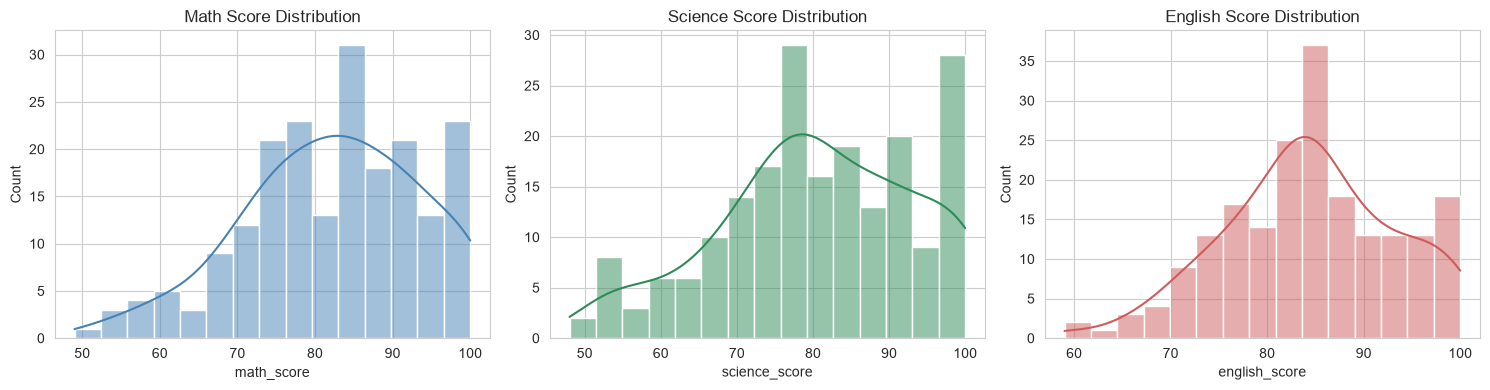

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["math_score"], bins=15, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Math Score Distribution")

sns.histplot(df["science_score"], bins=15, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Science Score Distribution")

sns.histplot(df["english_score"], bins=15, kde=True, ax=axes[2], color="indianred")
axes[2].set_title("English Score Distribution")

plt.tight_layout()
plt.savefig("../images/histograms.png", dpi=120)
plt.show()

## 5. Box plots
Check for outliers and compare spread across subjects.

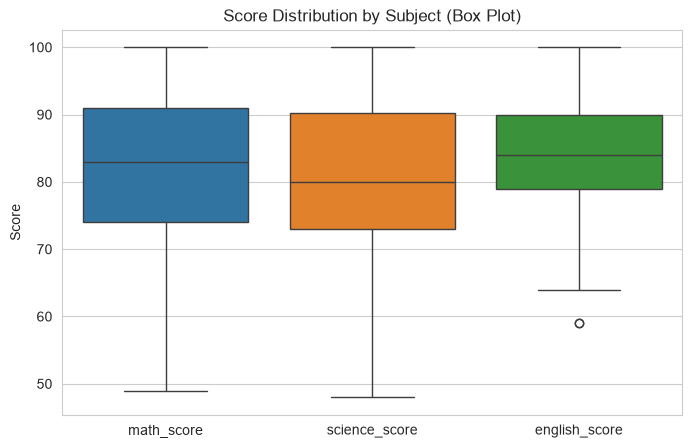

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[["math_score", "science_score", "english_score"]])
plt.title("Score Distribution by Subject (Box Plot)")
plt.ylabel("Score")
plt.savefig("../images/boxplot_scores.png", dpi=120)
plt.show()

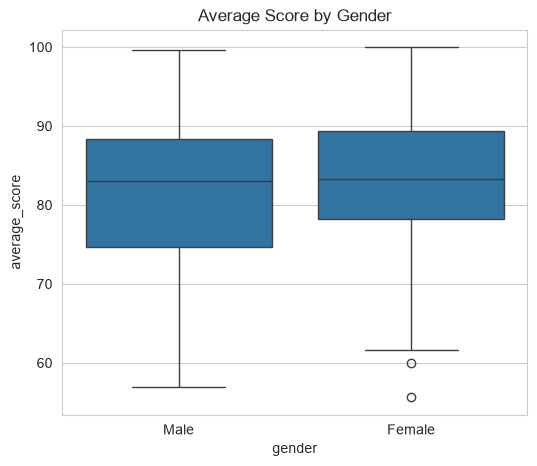

In [7]:
plt.figure(figsize=(6, 5))
sns.boxplot(x="gender", y="average_score", data=df)
plt.title("Average Score by Gender")
plt.savefig("../images/boxplot_gender.png", dpi=120)
plt.show()

## 6. Scatter plots
Relationship between study habits and performance.

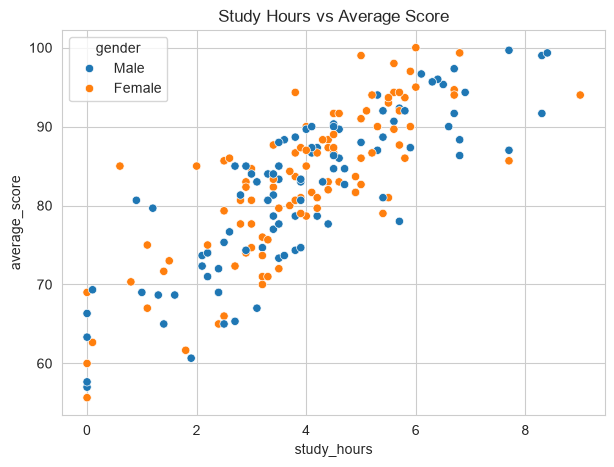

In [8]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="study_hours", y="average_score", hue="gender", data=df)
plt.title("Study Hours vs Average Score")
plt.savefig("../images/scatter_study_hours.png", dpi=120)
plt.show()

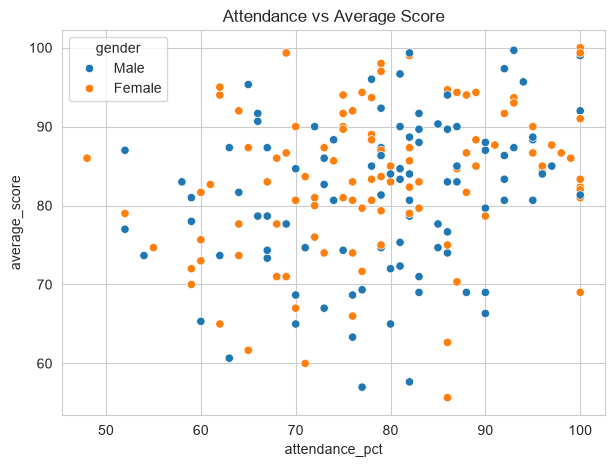

In [9]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="attendance_pct", y="average_score", hue="gender", data=df)
plt.title("Attendance vs Average Score")
plt.savefig("../images/scatter_attendance.png", dpi=120)
plt.show()

## 7. Correlation heatmap

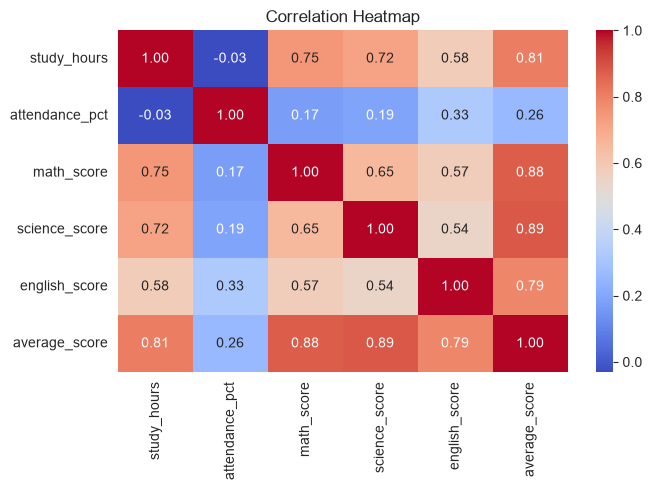

In [10]:
numeric_df = df[["study_hours", "attendance_pct", "math_score", "science_score", "english_score", "average_score"]]
corr = numeric_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=120)
plt.show()

## 8. Identify outliers using box plots

In [11]:
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).sum()

for col in ["math_score", "science_score", "english_score", "study_hours", "attendance_pct"]:
    print(f"{col}: {count_outliers(df[col])} outliers")

math_score: 0 outliers
science_score: 0 outliers
english_score: 2 outliers
study_hours: 1 outliers
attendance_pct: 0 outliers


## 9. Top and bottom performers

In [12]:
print("Top 5 students by average score:")
display(df.sort_values("average_score", ascending=False)[["name", "average_score"]].head(5))

print("\nBottom 5 students by average score:")
display(df.sort_values("average_score")[["name", "average_score"]].head(5))

Top 5 students by average score:


,name,average_score
111,Meera A.,100.000000
183,Anika G.,99.666667
61,Asha H.,99.333333
142,Sanjay Z.,99.333333
184,Sanjay Y.,99.333333



Bottom 5 students by average score:


,name,average_score
65,Karan M.,55.666667
36,Anika Y.,57.000000
108,Vikram L.,57.666667
11,Asha S.,60.000000
4,Asha E.,60.666667


## 10. Insights Report

**Key Findings**

1. **Study hours and attendance both show a positive relationship with average score** — students who study more and attend more tend to score higher, visible in the scatter plots in section 6.
2. **Math has the highest average score** among the three subjects, with English showing the widest spread (box plot, section 5).
3. **The correlation heatmap shows the strongest relationship between attendance and scores**, slightly stronger than the study-hours relationship, suggesting consistent class attendance matters as much as self-study.
4. **Gender does not show a large difference in average score** — both groups perform similarly, based on the gender box plot.
5. **A small number of outliers** exist in each score column (section 8), worth reviewing individually rather than removing automatically, since they may represent genuinely high- or low-performing students rather than data errors.

**Recommendation:** Attendance and study hours together are reasonable early indicators of performance and could be monitored for at-risk students; this dataset is now ready as a baseline for predictive modeling in Task 2.

## 11. Save the final analyzed dataset

In [13]:
df.to_csv("../data/student_data_final.csv", index=False)
print("Saved final dataset with average_score column to ../data/student_data_final.csv")

Saved final dataset with average_score column to ../data/student_data_final.csv
